In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, accuracy_score

In [9]:
csvpath = '../ickd__gpt-3-5-turbo__sst2___n1000000_s0_e67349.csv'
df = pd.read_csv(csvpath)
df.head()

,index,sentence,label,positive_prob,negative_prob
0,0,hide new secretions from the parental units,0,0.001140,0.998400
1,1,"contains no wit , only labored gags",0,-1.000000,0.994419
2,2,that loves its characters and communicates som...,1,0.999983,0.000013
3,3,remains utterly satisfied to remain the same t...,0,0.016052,0.982627
4,4,on the worst revenge-of-the-nerds clichés the ...,0,0.000070,0.999721


In [10]:
# clean -1 values for prob
df = df[(df['positive_prob'] != -1) & (df['negative_prob'] != -1)]

In [20]:
def adjust_temp(df, temperature):
    df['pos_logit'] = np.log(df['positive_prob']) / temperature
    df['neg_logit'] = np.log(df['negative_prob']) / temperature
    df['new_pos_prob'] = np.exp(df['pos_logit']) / (np.exp(df['pos_logit']) + np.exp(df['neg_logit']))
    df['new_neg_prob'] = np.exp(df['neg_logit']) / (np.exp(df['pos_logit']) + np.exp(df['neg_logit']))
    return df[['sentence', 'label', 'positive_prob', 'negative_prob', 'new_pos_prob', 'new_neg_prob']]

In [22]:
def plot_prob_dist(df):
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.hist(df['new_pos_prob'], bins=20, color='blue')
    plt.title('Positive Probabilities')
    plt.xlabel('Probability')
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    plt.hist(df['new_neg_prob'], bins=20, color='red')
    plt.title('Negative Probabilities')
    plt.xlabel('Probability')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

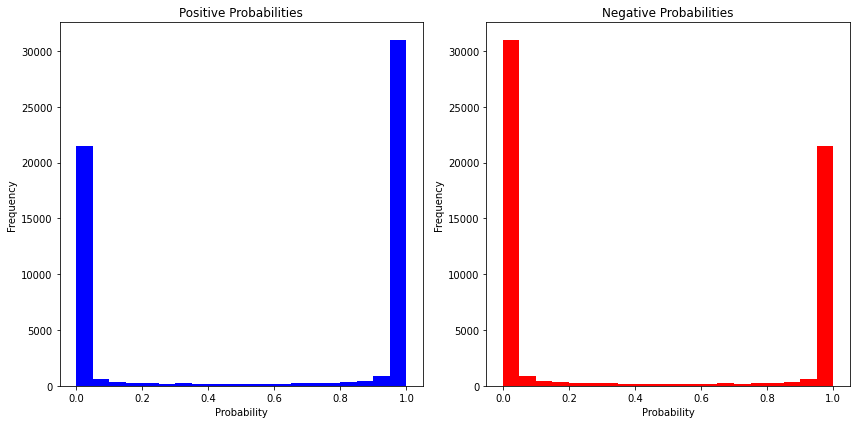

In [30]:
temp_1 = adjust_temp(df, 1)
plot_prob_dist(temp_1)

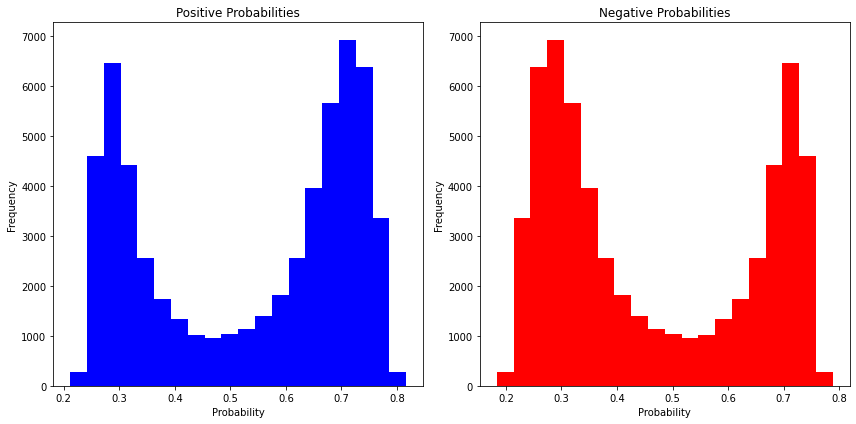

In [24]:
temp_10 = adjust_temp(df, 10)
plot_prob_dist(temp_10)

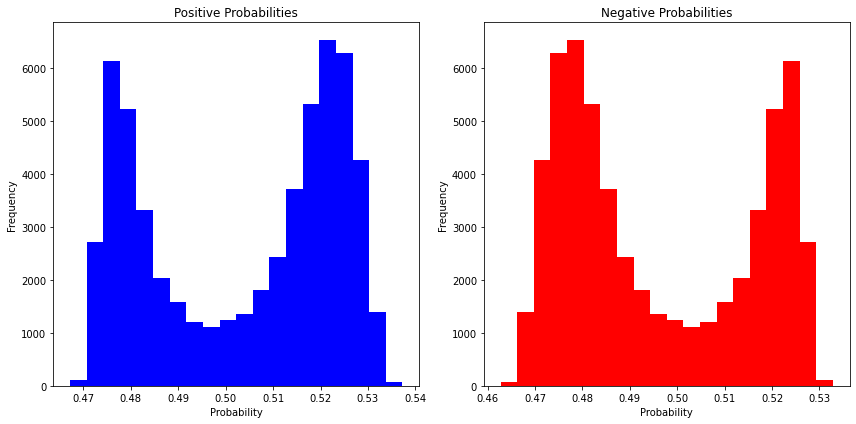

In [27]:
temp_100 = adjust_temp(df, 100)
plot_prob_dist(temp_100)

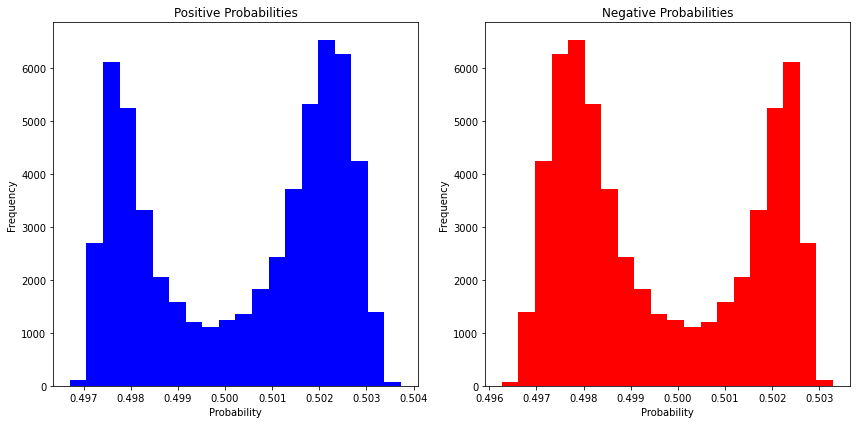

In [28]:
temp_1000 = adjust_temp(df, 1000)
plot_prob_dist(temp_1000)

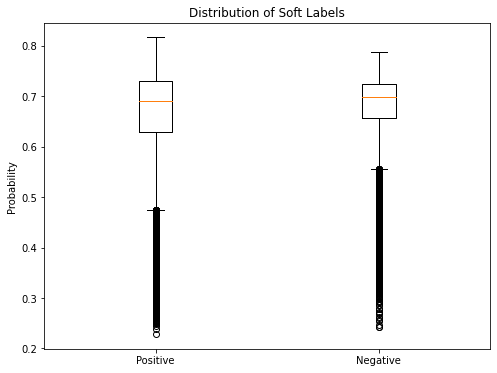

In [33]:
plt.figure(figsize=(8, 6))
plt.boxplot([temp_10[temp_10['label'] == 1]['new_pos_prob'], temp_10[temp_10['label'] == 0]['new_neg_prob']],
            labels=['Positive', 'Negative'])
plt.ylabel('Probability')
plt.title('Distribution of Soft Labels')
plt.show()

In [34]:
np.allclose(temp_10['new_pos_prob'] + temp_10['new_neg_prob'], 1)

True

In [39]:
temp_10['orig_soft_label'] = np.where(temp_10['positive_prob'] > temp_10['negative_prob'], 1, 0)
temp_10['new_soft_label']  = np.where(temp_10['new_pos_prob'] > temp_10['new_neg_prob'], 1, 0)


/Users/yooni/opt/anaconda3/envs/yooni/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/Users/yooni/opt/anaconda3/envs/yooni/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [43]:
# percentage of each 1 and 0 in the original labels
print("GT Label Dist\n", temp_10['label'].value_counts(normalize=True))
print("Orig Soft Label Dist\n", temp_10['orig_soft_label'].value_counts(normalize=True))
print("New Soft Label Dist\n", temp_10['new_soft_label'].value_counts(normalize=True))

GT Label Dist
 1    0.624207
0    0.375793
Name: label, dtype: float64
Orig Soft Label Dist
 1    0.586925
0    0.413075
Name: orig_soft_label, dtype: float64
New Soft Label Dist
 1    0.586925
0    0.413075
Name: new_soft_label, dtype: float64


In [50]:
def calculate_metrics(df, label_col, soft_label_col, prob_col, threshold_low, threshold_high, pos_label=1):
    if prob_col:
        subset_df = df[(df[prob_col] >= threshold_low) & (df[prob_col] <= threshold_high)]
    else:
        subset_df = df
    precision = precision_score(subset_df[label_col], subset_df[soft_label_col], pos_label=pos_label, average='binary')
    recall = recall_score(subset_df[label_col], subset_df[soft_label_col], pos_label=pos_label, average='binary')
    accuracy = accuracy_score(subset_df[label_col], subset_df[soft_label_col])
    count = len(subset_df)
    percentage = 100 * count / len(df)
    print(f"Subset count: {count} ({percentage:.2f}%)")
    print(f'Precision: {precision}, Recall: {recall}, Accuracy: {accuracy}\n')

In [58]:
# Overall metrics
print("Overall Metrics")
calculate_metrics(temp_10, 'label', 'new_soft_label', None, 0, 1)

# Metrics for uncertain positive cases
print("Uncertain Positive Metrics")
calculate_metrics(temp_10, 'label', 'new_soft_label', 'new_pos_prob', 0.4, 0.6)

# Metrics for uncertain negative cases
print("Uncertain Negative Metrics")
calculate_metrics(temp_10, 'label', 'new_soft_label', 'new_pos_prob', 0.4, 0.6, pos_label=0)

# # Metrics for certain positive cases
print("Certain Positive Metrics")
calculate_metrics(temp_10, 'label', 'new_soft_label', 'new_pos_prob', 0.7, 1)

# # Metrics for certain negative cases
print("Certain Negative Metrics")
calculate_metrics(temp_10, 'label', 'new_soft_label', 'new_neg_prob', 0.7, 1, pos_label=0)

Overall Metrics
Subset count: 57883 (100.00%)
Precision: 0.9727136255261531, Recall: 0.9146162575074036, Accuracy: 0.930687766701795

Uncertain Positive Metrics
Subset count: 8073 (13.95%)
Precision: 0.8573336300912531, Recall: 0.6649404453650958, Accuracy: 0.6801684627771585

Uncertain Negative Metrics
Subset count: 8073 (13.95%)
Precision: 0.45782122905027933, Recall: 0.718859649122807, Accuracy: 0.6801684627771585

Certain Positive Metrics
Subset count: 16010 (27.66%)
Precision: 0.9984384759525297, Recall: 1.0, Accuracy: 0.9984384759525297

Certain Negative Metrics
Subset count: 10908 (18.84%)
Precision: 0.9871653832049871, Recall: 1.0, Accuracy: 0.9871653832049871



In [44]:
def expected_calibration_error(samples, true_labels, M=10):
    # uniform binning approach with M number of bins
    bin_boundaries = np.linspace(0, 1, M + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    # get max probability per sample i
    confidences = np.max(samples, axis=1)
    # print(confidences)
    # get predictions from confidences (positional in this case)
    predicted_label = np.argmax(samples, axis=1)
    predicted_label = np.where(predicted_label == 1, 0, 1)
    # print(predicted_label)
    # print(true_labels)

    # get a boolean list of correct/false predictions
    accuracies = predicted_label == true_labels
    # print(accuracies)

    ece = np.zeros(1)
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # determine if sample is in bin m (between bin lower & upper)
        in_bin = np.logical_and(confidences > bin_lower.item(), confidences <= bin_upper.item())
        # can calculate the empirical probability of a sample falling into bin m: (|Bm|/n)
        prob_in_bin = in_bin.mean()

        if prob_in_bin.item() > 0:
            # get the accuracy of bin m: acc(Bm)
            accuracy_in_bin = accuracies[in_bin].mean()
            # get the average confidence of bin m: conf(Bm)
            avg_confidence_in_bin = confidences[in_bin].mean()
            # calculate |acc(Bm) - conf(Bm)| * (|Bm|/n) for bin m and add to the total ECE
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prob_in_bin
    return ece


In [45]:
samples = np.column_stack((temp_10['new_pos_prob'], temp_10['new_neg_prob']))
true_labels = temp_10['label'].values

M = 10  # Number of bins
ece = expected_calibration_error(samples, true_labels, M=M)
print(f'Expected Calibration Error: {ece[0]}')

Expected Calibration Error: 0.251192960129596
